<a href="https://colab.research.google.com/github/joseph-e-kent/ctrl_alt_elite/blob/master/notebooks/starter_signs_silas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Note: After you run this cell, the training and test data will be available in
# the file browser. (Click the folder icon on the left to view it)
#
# If you don't see the data after the cell completes, click the refresh button
# in the file browser (folder icon with circular arrow)

# First, let's download and unzip the data
!echo "Downloading files..."
!wget -q https://github.com/byui-cse/cse450-course/raw/master/data/roadsigns/training1.zip
!wget -q https://github.com/byui-cse/cse450-course/raw/master/data/roadsigns/training2.zip
!wget -q https://github.com/byui-cse/cse450-course/raw/master/data/roadsigns/holdout.zip
!wget -q https://github.com/byui-cse/cse450-course/raw/master/data/roadsigns/mini_holdout.zip
!wget -q https://github.com/byui-cse/cse450-course/raw/master/data/roadsigns/mini_holdout_answers.csv

!echo "Unzipping files..."
!unzip -q /content/training1.zip
!unzip -q /content/training2.zip
!unzip -q /content/holdout.zip
!unzip -q /content/mini_holdout.zip

# Combine the two traning directories
!echo "Merging training data..."
!mkdir /content/training
!mv /content/training1/* /content/training
!mv /content/training2/* /content/training

# Cleanup
!echo "Cleaning up..."
!rmdir /content/training1
!rmdir /content/training2
!rm training1.zip
!rm training2.zip
!rm holdout.zip
!rm mini_holdout.zip

!echo "Data ready."

Unzipping files...
Merging training data...
Cleaning up...
Data ready.


In [17]:
# Import libraries
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import datasets, layers, models
import matplotlib.pyplot as plt
import numpy as np
from tensorflow.keras.preprocessing import image_dataset_from_directory
from tensorflow.keras.applications import ConvNeXtTiny
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.applications.convnext import preprocess_input

In [11]:
# We're using keras' ImageDataGenerator class to load our image data.
# See (https://keras.io/api/preprocessing/image/#imagedatagenerator-class) for details
#
# A couple of things to note:
# 1. We're specifying a number for the seed, so we'll always get the same shuffle and split of our images.
# 2. Class names are inferred automatically from the image subdirectory names.
# 3. We're splitting the training data into 80% training, 20% validation.

BATCH_SIZE = 100

training_dir = '/content/training/'
image_size = (100, 100)

# Split up the training data images into training and validations sets
# We'll use and ImageDataGenerator to do the splits
# ImageDataGenerator can also be used to do preprocessing and agumentation on the files as can be seen with rescale

'''
train_datagen = ImageDataGenerator(
        rescale=1./255,
        validation_split=.2
)

validation_datagen = ImageDataGenerator(
        rescale=1./255,
        validation_split=.2
)
'''

train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    validation_split=0.2
)

validation_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    validation_split=0.2
)

train_generator = train_datagen.flow_from_directory(
        training_dir,
        target_size = image_size,
        subset="training",
        batch_size=BATCH_SIZE,
        class_mode='sparse',
        seed=42,shuffle=True)
validation_generator = validation_datagen.flow_from_directory(
        training_dir,
        target_size=image_size,
        batch_size=BATCH_SIZE,
        class_mode='sparse',
        subset="validation",
        seed=42)

Found 31368 images belonging to 43 classes.
Found 7841 images belonging to 43 classes.


In [12]:
#these might come in handy
target_names = ['Speed_20', 'Speed_30', 'Speed_50', 'Speed_60', 'Speed_70',
               'Speed_80','Speed_Limit_Ends', 'Speed_100', 'Speed_120', 'Overtaking_Prohibited',
               'Overtakeing_Prohibited_Trucks', 'Priority', 'Priority_Road_Ahead', 'Yield', 'STOP',
               'Entry_Forbidden', 'Trucks_Forbidden', 'No_Entry(one-way traffic)', 'General Danger(!)', 'Left_Curve_Ahead',
               'Right_Curve_Ahead', 'Double_Curve', 'Poor_Surface_Ahead', 'Slippery_Surface_Ahead', 'Road_Narrows_On_Right',
               'Roadwork_Ahead', 'Traffic_Light_Ahead', 'Warning_Pedestrians', 'Warning_Children', 'Warning_Bikes',
               'Ice_Snow', 'Deer_Crossing', 'End_Previous_Limitation', 'Turning_Right_Compulsory', 'Turning_Left_Compulsory',
               'Ahead_Only', 'Straight_Or_Right_Mandatory', 'Straight_Or_Left_Mandatory', 'Passing_Right_Compulsory', 'Passing_Left_Compulsory',
               'Roundabout', 'End_Overtaking_Prohibition', 'End_Overtaking_Prohibition_Trucks']

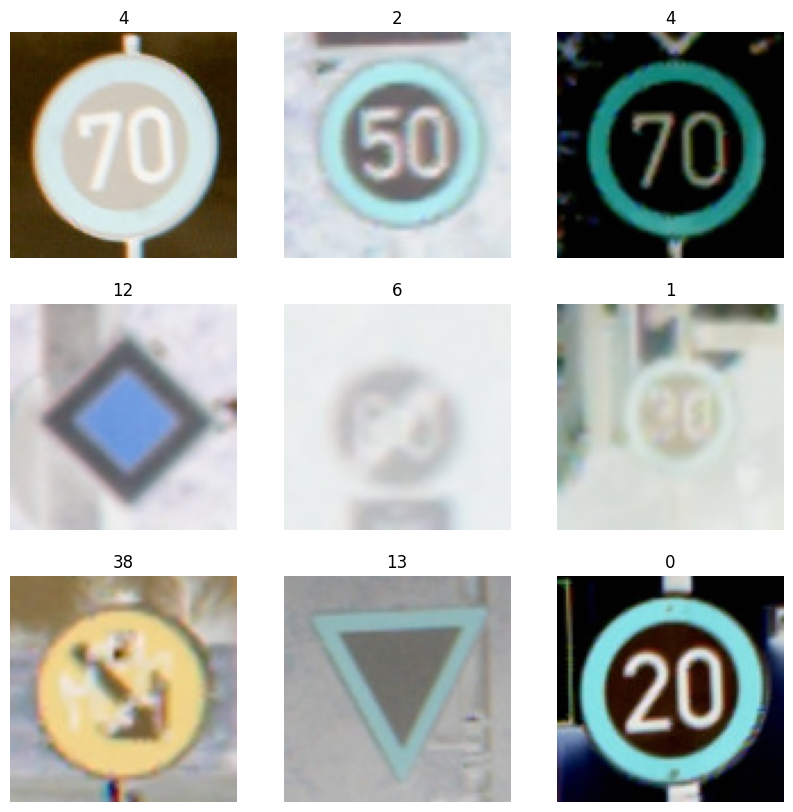

In [13]:
# View 9 images and their class labels
plt.figure(figsize=(10, 10))
images, labels = next(train_generator)  # Assuming train_generator is a generator
batch_size = images.shape[0]

for i in range(min(9, batch_size)):
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow((images[i] * 255).astype("uint8"))
    plt.title(int(labels[i]))
    plt.axis("off")

plt.show()

In [18]:
'''
base_model = tf.keras.applications.InceptionV3(input_shape=(100, 100, 3),
                                               include_top=False,
                                               weights='imagenet')
'''

tf.keras.mixed_precision.set_global_policy('mixed_float16')

base_model = tf.keras.applications.ConvNeXtTiny(
    input_shape=(100, 100, 3),
    include_top=False,
    weights='imagenet'
)

111650432/111650432 ━━━━━━━━━━━━━━━━━━━━ 7s 0us/step


In [19]:
# Build a model...
'''
# Old model
model = models.Sequential()
model.add(layers.Conv2D(32, (3, 3), activation='relu', input_shape=(100, 100, 3)))
# model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(64, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(128, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(256, (3, 3), activation='relu'))
model.add(layers.Flatten())
model.add(layers.Dense(64, activation='relu'))
model.add(layers.Dense(43))
model.summary()
'''

reg = tf.keras.regularizers.l2(1e-4)

model = tf.keras.Sequential()
model.add(base_model)
model.add(layers.GlobalAveragePooling2D())
model.add(layers.Dense(512, activation='gelu', kernel_regularizer=reg))
model.add(layers.BatchNormalization())
model.add(layers.Dropout(0.6))
model.add(layers.Dense(256, activation='gelu', kernel_regularizer=reg))
model.add(layers.BatchNormalization())
model.add(layers.Dropout(0.4))
model.add(layers.Dense(len(target_names), activation='softmax'))

model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ convnext_tiny (Functional)      │ (None, 3, 3, 768)      │    27,820,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 768)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 512)            │       393,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 43)             │        11,051 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 28,359,307 (108.18 MB)

 Trainable params: 28,357,771 (108.18 MB)

 Non-trainable params: 1,536 (6.00 KB)

In [20]:
# Change monitor to f1 score

checkpoint = tf.keras.callbacks.ModelCheckpoint(
    filepath='best_model.keras',
    monitor='val_accuracy',
    mode='max',
    save_best_only=True,
    verbose=1
)

early_stopping_callback = EarlyStopping(
    monitor='val_accuracy',
    patience=5,
    mode='max',
    restore_best_weights=True,
    verbose=1
)

model.compile(
    optimizer=tf.keras.optimizers.AdamW(learning_rate=0.0005, weight_decay=1e-4),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    metrics=['accuracy']
)

EPOCHS = 20

model.fit(train_generator, epochs=20, validation_data=validation_generator,
          callbacks=[checkpoint, early_stopping_callback])

Epoch 1/20
314/314 ━━━━━━━━━━━━━━━━━━━━ 0s 728ms/step - accuracy: 0.5978 - loss: 1.8722
Epoch 1: val_accuracy improved from None to 0.98865, saving model to best_model.keras

Epoch 1: finished saving model to best_model.keras
314/314 ━━━━━━━━━━━━━━━━━━━━ 487s 1s/step - accuracy: 0.8426 - loss: 0.7682 - val_accuracy: 0.9886 - val_loss: 0.1423
Epoch 2/20
314/314 ━━━━━━━━━━━━━━━━━━━━ 0s 319ms/step - accuracy: 0.9959 - loss: 0.1204
Epoch 2: val_accuracy did not improve from 0.98865
314/314 ━━━━━━━━━━━━━━━━━━━━ 104s 331ms/step - accuracy: 0.9956 - loss: 0.1184 - val_accuracy: 0.9881 - val_loss: 0.1475
Epoch 3/20
314/314 ━━━━━━━━━━━━━━━━━━━━ 0s 315ms/step - accuracy: 0.9980 - loss: 0.1030
Epoch 3: val_accuracy did not improve from 0.98865
314/314 ━━━━━━━━━━━━━━━━━━━━ 103s 328ms/step - accuracy: 0.9971 - loss: 0.1053 - val_accuracy: 0.9837 - val_loss: 0.1726
Epoch 4/20
314/314 ━━━━━━━━━━━━━━━━━━━━ 0s 313ms/step - accuracy: 0.9940 - loss: 0.1166
Epoch 4: val_accuracy did not improve from 0.988

In [1]:
from google.colab import drive
import shutil
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
source = '/content/best_model.keras'
destination = '/content/drive/MyDrive/models/best_model.keras'
shutil.move(source, destination)

FileNotFoundError: [Errno 2] No such file or directory: '/content/best_model.keras'

In [ ]:
# Load the model from drive
model_path = '/content/drive/MyDrive/models/best_model.keras'
model = tf.keras.models.load_model(model_path)

In [ ]:
test_dir = '/content/'

test_datagen = ImageDataGenerator(rescale=1./255)
test_generator = test_datagen.flow_from_directory(
        test_dir,
        classes=['mini_holdout'],
        target_size=image_size,
        class_mode='sparse',
        shuffle=False)
probabilities = model.predict(test_generator)
predictions = [np.argmax(probas) for probas in probabilities]

my_predictions = pd.DataFrame(predictions, columns=['ClassId'])
my_predictions.to_csv('ctrl-alt-elite-module5-predictions.csv', index=False)

Found 201 images belonging to 1 classes.


7/7 ━━━━━━━━━━━━━━━━━━━━ 14s 1s/step


In [ ]:
from sklearn.metrics import accuracy_score, f1_score

# Load the ground truth answers
mini_holdout_answers = pd.read_csv('/content/mini_holdout_answers.csv')

# Assuming the order of predictions matches the order in mini_holdout_answers.csv
true_labels = mini_holdout_answers['ClassId'].values

# Calculate accuracy
accuracy = accuracy_score(true_labels, predictions)

# Calculate F1 score
f1 = f1_score(true_labels, predictions, average='weighted') # 'weighted' is good for imbalanced datasets

print(f"Model Accuracy on Mini Holdout: {accuracy:.4f}")
print(f"Model F1 Score on Mini Holdout: {f1:.4f}")

Model Accuracy on Mini Holdout: 0.9602
Model F1 Score on Mini Holdout: 0.9602


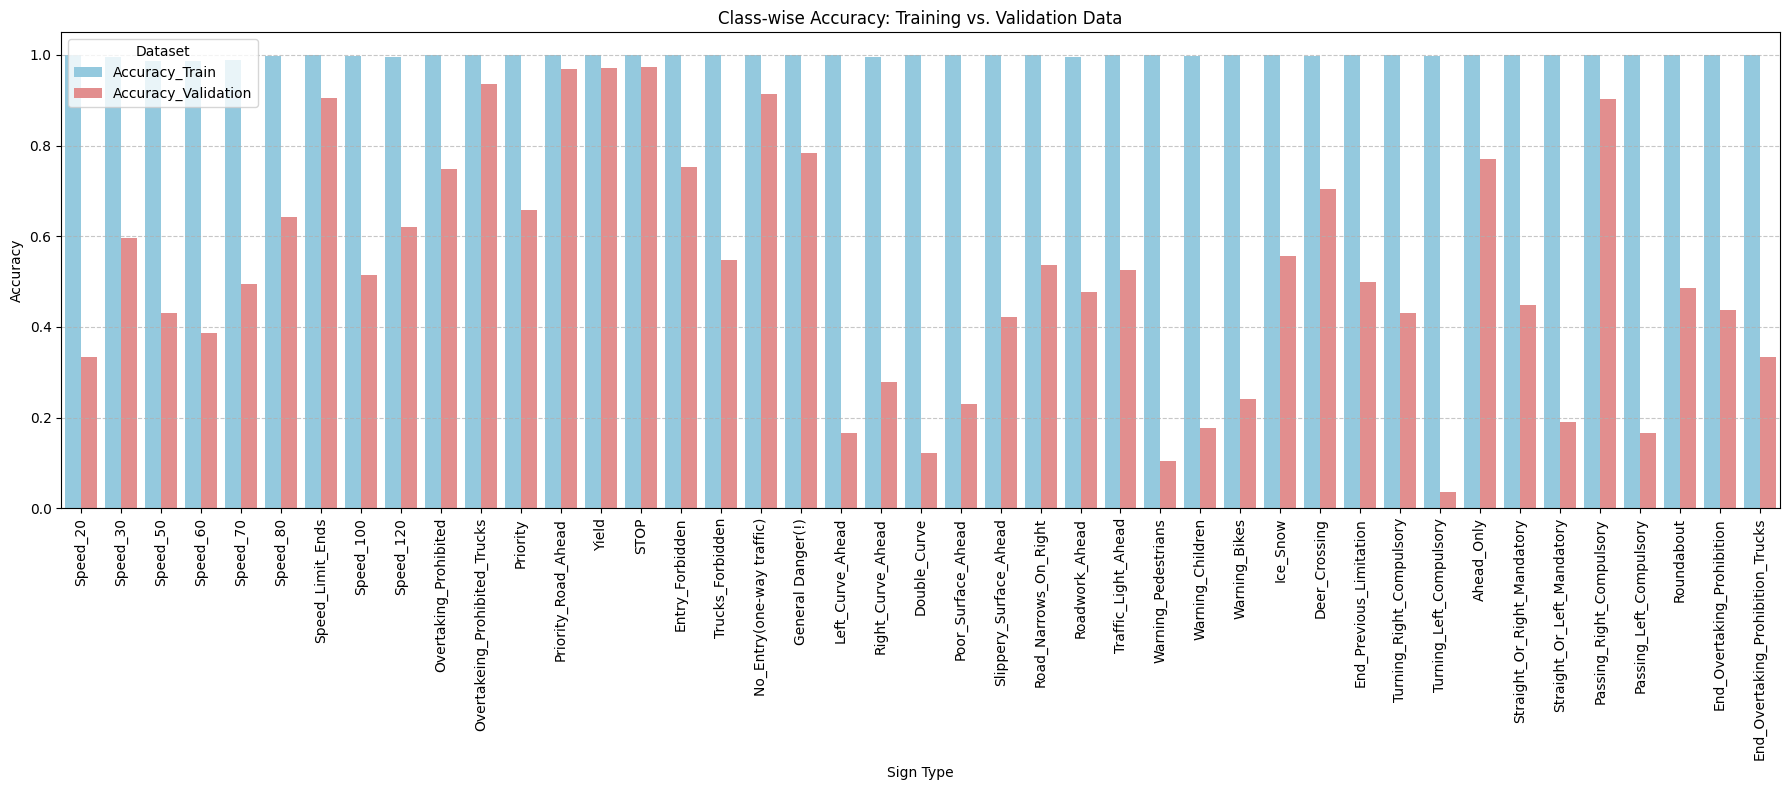

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from collections import defaultdict

# Function to get true labels and predictions from a generator
def get_labels_and_predictions(generator, model):
    all_true_labels = []
    all_predicted_labels = []
    generator.reset() # Ensure generator starts from beginning

    num_batches = len(generator)
    for i in range(num_batches):
        images, true_labels_batch = generator[i]
        all_true_labels.extend(true_labels_batch)
        batch_predictions = model.predict(images, verbose=0)
        all_predicted_labels.extend(np.argmax(batch_predictions, axis=1))
    return np.array(all_true_labels), np.array(all_predicted_labels)

# Function to calculate class-wise accuracy
def calculate_class_accuracy_df(true_labels, predicted_labels, target_names):
    correct_predictions_per_class = defaultdict(int)
    total_predictions_per_class = defaultdict(int)

    for true_label, predicted_label in zip(true_labels, predicted_labels):
        true_label_int = int(true_label) # Ensure integer
        total_predictions_per_class[true_label_int] += 1
        if true_label_int == predicted_label:
            correct_predictions_per_class[true_label_int] += 1

    class_accuracy_list = []
    for class_id in sorted(total_predictions_per_class.keys()):
        accuracy = (correct_predictions_per_class[class_id] / total_predictions_per_class[class_id]) if total_predictions_per_class[class_id] > 0 else 0
        class_accuracy_list.append({
            'Class ID': class_id,
            'Sign Name': target_names[class_id],
            'Accuracy': accuracy,
            'Total Samples': total_predictions_per_class[class_id]
        })
    return pd.DataFrame(class_accuracy_list)

# Get true labels and predictions for training and validation sets
train_true_labels, train_predicted_labels = get_labels_and_predictions(train_generator, model)
validation_true_labels, validation_predicted_labels = get_labels_and_predictions(validation_generator, model)

# Calculate class-wise accuracy for both sets
train_class_accuracy_df = calculate_class_accuracy_df(train_true_labels, train_predicted_labels, target_names)
validation_class_accuracy_df = calculate_class_accuracy_df(validation_true_labels, validation_predicted_labels, target_names)

# Merge for plotting
merged_accuracy_df = pd.merge(train_class_accuracy_df[['Class ID', 'Sign Name', 'Accuracy']],
                              validation_class_accuracy_df[['Class ID', 'Sign Name', 'Accuracy']],
                              on=['Class ID', 'Sign Name'],
                              suffixes=('_Train', '_Validation'))

melted_accuracy_df = merged_accuracy_df.melt(id_vars=['Class ID', 'Sign Name'], var_name='Dataset', value_name='Accuracy')

# Plotting the distributions
plt.figure(figsize=(18, 8))
sns.barplot(x='Sign Name', y='Accuracy', hue='Dataset', data=melted_accuracy_df,
            palette={'Accuracy_Train': 'skyblue', 'Accuracy_Validation': 'lightcoral'})
plt.title('Class-wise Accuracy: Training vs. Validation Data')
plt.xlabel('Sign Type')
plt.ylabel('Accuracy')
plt.xticks(rotation=90)
plt.legend(title='Dataset')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import numpy as np

# Load the ground truth answers
mini_holdout_answers = pd.read_csv('/content/mini_holdout_answers.csv')

# Assuming the order of predictions matches the order in mini_holdout_answers.csv
true_labels = mini_holdout_answers['ClassId'].values

# Calculate accuracy
accuracy = accuracy_score(true_labels, predictions)
print(f"Model Accuracy on Mini Holdout: {accuracy:.4f}")

# Create a DataFrame for easier comparison and visualization
comparison_df = pd.DataFrame({
    'True Label': true_labels,
    'Predicted Label': predictions
})

Model Accuracy on Mini Holdout: 0.6866



Accuracy per Sign Type:


,Class ID,Sign Name,Accuracy,Total Samples
11,12,Priority_Road_Ahead,1.000000,7
13,14,STOP,1.000000,4
29,31,Deer_Crossing,1.000000,1
16,17,No_Entry(one-way traffic),1.000000,7
12,13,Yield,0.900000,10
9,10,Overtakeing_Prohibited_Trucks,0.833333,12
35,38,Passing_Right_Compulsory,0.777778,9
33,35,Ahead_Only,0.750000,4
8,9,Overtaking_Prohibited,0.700000,10
24,26,Traffic_Light_Ahead,0.666667,3


/tmp/ipykernel_30788/2521056892.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Sign Name', y='Accuracy', data=class_accuracy_df.sort_values(by='Accuracy', ascending=False), palette='viridis')


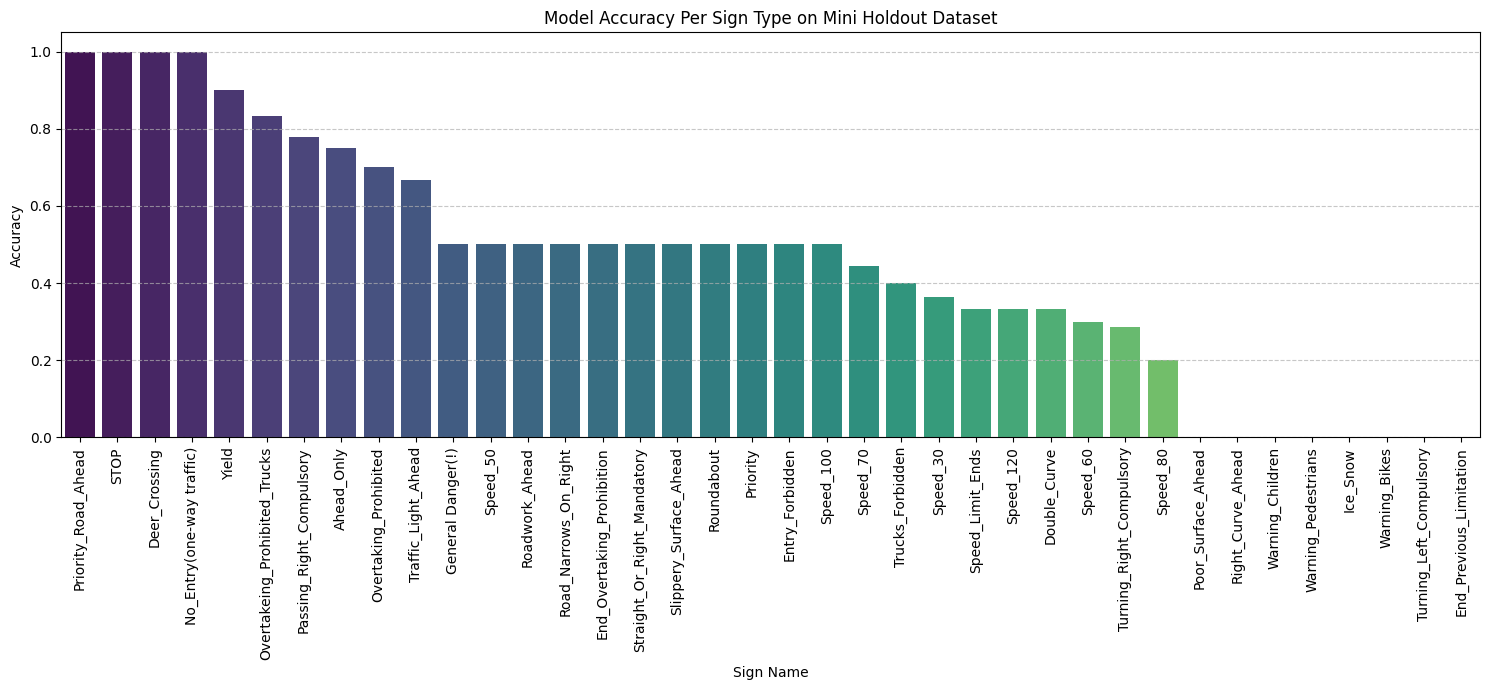

In [ ]:
from collections import defaultdict
import seaborn as sns # Import seaborn for plotting

# Map class IDs to their corresponding names
comparison_df['True Sign Name'] = comparison_df['True Label'].map(lambda x: target_names[x])
comparison_df['Predicted Sign Name'] = comparison_df['Predicted Label'].map(lambda x: target_names[x])

# Calculate correct predictions per class
correct_predictions_per_class = defaultdict(int)
total_predictions_per_class = defaultdict(int)

for index, row in comparison_df.iterrows():
    true_label = row['True Label']
    predicted_label = row['Predicted Label']
    total_predictions_per_class[true_label] += 1
    if true_label == predicted_label:
        correct_predictions_per_class[true_label] += 1

# Calculate accuracy per class
class_accuracy = []
for class_id in sorted(total_predictions_per_class.keys()):
    accuracy = (correct_predictions_per_class[class_id] / total_predictions_per_class[class_id]) if total_predictions_per_class[class_id] > 0 else 0
    class_accuracy.append({
        'Class ID': class_id,
        'Sign Name': target_names[class_id],
        'Accuracy': accuracy,
        'Total Samples': total_predictions_per_class[class_id]
    })

class_accuracy_df = pd.DataFrame(class_accuracy)

print("\nAccuracy per Sign Type:")
display(class_accuracy_df.sort_values(by='Accuracy', ascending=False))

# Visualize accuracy per sign type
fig, ax = plt.subplots(figsize=(15, 7))
sns.barplot(x='Sign Name', y='Accuracy', data=class_accuracy_df.sort_values(by='Accuracy', ascending=False), palette='viridis')
plt.title('Model Accuracy Per Sign Type on Mini Holdout Dataset')
plt.xlabel('Sign Name')
plt.ylabel('Accuracy')
plt.xticks(rotation=90)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Incorrectly classified: 8 / 201


,Filename,True Label,Predicted Label
1,00001.jpg,1,5
50,00050.jpg,25,21
114,00114.jpg,30,23
127,00127.jpg,30,21
147,00147.jpg,41,9
163,00163.jpg,25,28
176,00176.jpg,3,5
198,00198.jpg,18,11


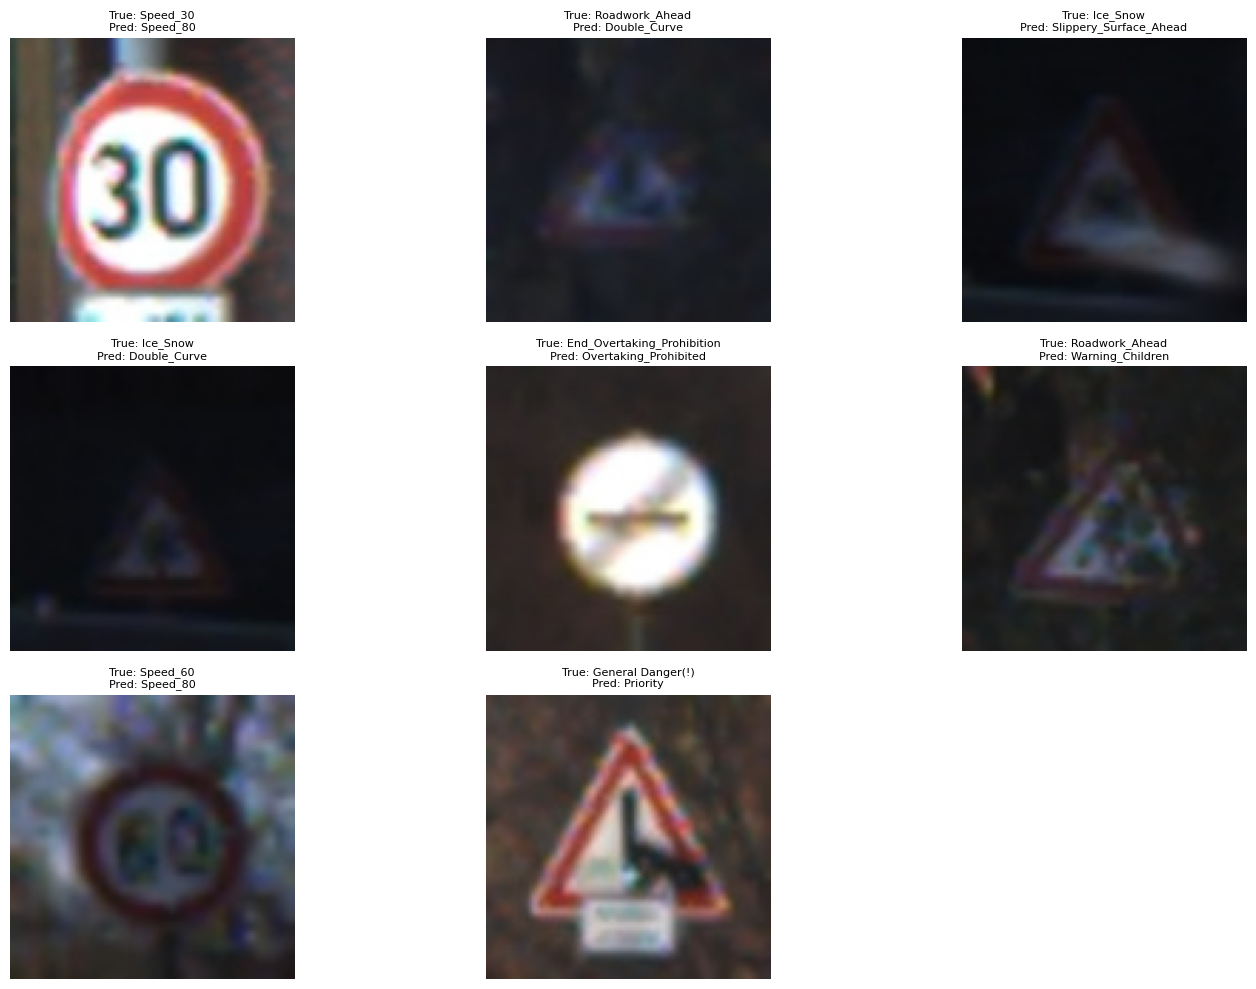

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

comparison_df = pd.DataFrame({
    'Filename': mini_holdout_answers['Filename'].values,
    'True Label': true_labels,
    'Predicted Label': predictions
})

incorrect_df = comparison_df[comparison_df['True Label'] != comparison_df['Predicted Label']]

print(f"Incorrectly classified: {len(incorrect_df)} / {len(comparison_df)}")
display(incorrect_df.head(10))

plt.figure(figsize=(15, 10))
num_to_display = min(9, len(incorrect_df))

for i in range(num_to_display):
    row = incorrect_df.iloc[i]
    true_label = int(row['True Label'])
    predicted_label = int(row['Predicted Label'])
    image_path = f"/content/mini_holdout/{row['Filename']}"

    plt.subplot(3, 3, i + 1)
    img = mpimg.imread(image_path)
    plt.imshow(img)
    plt.title(f"True: {target_names[true_label]}\nPred: {target_names[predicted_label]}", fontsize=8)
    plt.axis('off')

plt.tight_layout()
plt.show()

## Testing the model
Once you have built and trained your model, the next step is to run the mini holdout images through it and see how well your model does at making predictions for images it has never seen before.

Since loading these images and formatting them for the model can be tricky, you may find the following code useful. This code only uses your model to predict the class label for a given image. You'll still need to compare those predictions to the "ground truth" class labels in `mini_holdout_answers.csv` to evaluate how well the model does.

Previously, you were given a file that would check your results. This time you're given the answers to the first mini holdout dataset. You'll need to compare those predictions against the "ground truth" class labels in `mini_holdout_answers.csv` to evaluate how well the model does.

Make sure to use the insights gained from the mini hold out dataset in your executive summary.


```
from tensorflow.keras.preprocessing import image_dataset_from_directory
test_dir = '/content/'

test_datagen = ImageDataGenerator(rescale=1./255)
test_generator = test_datagen.flow_from_directory(
        test_dir,
        classes=['mini_holdout'],
        target_size=image_size,
        class_mode='sparse',
        shuffle=False)
probabilities = model.predict(test_generator)
predictions = [np.argmax(probas) for probas in probabilities]
```



##Mini Hold out Dataset


Once you feel confident, you will need to predict for the full holdout dataset using the following code, and submit your csv file:

```
from tensorflow.keras.preprocessing import image_dataset_from_directory
test_dir = '/content/'

test_datagen = ImageDataGenerator(rescale=1./255)
test_generator = test_datagen.flow_from_directory(
        test_dir,
        classes=['holdout'],
        target_size=image_size,
        class_mode='sparse',
        shuffle=False)
probabilities = model.predict(test_generator)
predictions = [np.argmax(probas) for probas in probabilities]
```